# Model V5.2 Validation

Run this mirroring the real data

Real data used to validate uses Bluetti Elite 200 power stations, without any solar.

53 households, some with multiple batteries, performing in events over a 3-day period for a total of 237 individual event responses.

Validation goals:
* maximum flexibility

In [19]:
import pandas as pd
import numpy as np
import requests
import pvlib
import matplotlib.pyplot as plt  # for visualization
import math
from datetime import datetime
from statistics import median
from statistics import mean
from keys import *
from typing import List, Dict, Any
from collections import deque
import glob

In [20]:
#GLOBALS
#note that these coordinates are the inputs for the NREL API,
#the coordinates used by the NREL API for the weather file are slightly different
#see below
lat = 40.7128
long = -74.0060

#optimize for summer when DR program is in effect
#also minimizes shading from buildings during PSH
tilt = lat #math.floor(lat - 15)

#default to south facing
azimuth = 180

print(f"tilt: {str(tilt)}, azimuth: {str(azimuth)}")

#14% losses
shading = .86

#max 99% efficient mppt battery charger - used for PV to battery
mppt = .99

# conversion rate when charging battery from grid - used for grid to battery
acToDC = .95

# microinverter conversion efficiency is 95% - used for PV to grid
miEff = 0.95

# max 80% depth of discharge for LiFePO4 batteries under normal circumstances
# & 95% to maximize flexibiltiy during events
LiFePOdod = 0.80
LiFePOdod_event = 0.96

#Max Hardware Sizes
pvMaxW = 1200

#PV degredation rate is assumed to be 1% annually
DEG_RATE = 0.01

#days in the months May - September
daysInMonth = [31,30,31,31,30]
drSeasonStartDay = 121

# self consumption of both controller and power station
controllerSC = 1 #Raspberry Pi Zero 2W controller self-consumption
powerStationSC = 8.62 #power station no-load self-consumption with AC outputs turned on
scWDC = controllerSC + powerStationSC
dailySelfConsumptionWhDC = scWDC * 24


tilt: 40.7128, azimuth: 180


# Validation Data

In [21]:
# ---- Load the real event-level observations ----
observed_df = pd.read_csv('power_station_validation/validation_hourly_observed_20260727_125334.csv')

# All deployed hardware is the same unit
BATTERY_MODEL = 'Elite 200V2'

observed_df.head()

,customer,battery_id,battery_model,event,event_date,timestamp,hour_of_day,soc_pct,observed_flex_kW,observed_load_kW,observed_grid_kW,observed_batterydischarge_kW,was_charging_in_window
0,1,1,Elite 200V2,1,2025-06-23,2025-06-23 16:00:00-04:00,16,97.066667,0.174750,0.174750,0.000000,0.174750,False
1,1,1,Elite 200V2,1,2025-06-23,2025-06-23 17:00:00-04:00,17,86.866667,0.459417,0.459417,0.000000,0.459417,False
2,1,1,Elite 200V2,1,2025-06-23,2025-06-23 18:00:00-04:00,18,63.066667,0.095917,0.095917,0.000000,0.095917,False
3,1,1,Elite 200V2,1,2025-06-23,2025-06-23 19:00:00-04:00,19,59.000000,0.117950,0.117950,0.000000,0.117950,False
4,1,1,Elite 200V2,2,2025-06-24,2025-06-24 16:00:00-04:00,16,100.000000,0.070967,0.133433,0.062467,0.070967,False


In [22]:
observed_df.describe()

,customer,battery_id,event,hour_of_day,soc_pct,observed_flex_kW,observed_load_kW,observed_grid_kW,observed_batterydischarge_kW
count,924.000000,924.000000,924.000000,924.000000,923.000000,922.000000,922.000000,922.000000,922.000000
mean,32.181818,1.350649,2.000000,16.772727,73.266685,0.262801,0.429487,0.166707,0.262801
std,16.962691,0.529099,0.816939,1.933418,33.089280,0.327700,0.448966,0.355372,0.327700
min,1.000000,1.000000,1.000000,11.000000,1.666667,-0.382783,0.000000,0.000000,-0.382783
25%,19.000000,1.000000,1.000000,16.000000,51.966667,0.000000,0.000000,0.000000,0.000000
50%,32.000000,1.000000,2.000000,17.000000,93.000000,0.109592,0.362167,0.000000,0.109592
75%,47.000000,2.000000,3.000000,18.000000,99.000000,0.454687,0.709992,0.100775,0.454687
max,60.000000,3.000000,3.000000,22.000000,100.000000,1.628250,1.676217,1.676850,1.628250


In [23]:
print(f'{len(observed_df['customer'].unique())} households')
print(f'events in data: {948.000000/4}')

53 households
events in data: 237.0


## Power Station Data


In [32]:
hardware_df = pd.read_csv('data/PowerStations_LiFePo4_June29_2026.csv')

#clean data - these columns aren't used in this analysis
hardware_df = hardware_df.drop(columns=['Link','Min PV Voltage','Max PV Voltage','Warranty Years','Lifespan','Notes','Estimated Full Charge Time','Estimated Minimum Grid Charge Efficiency'])

retailPriceColumns = ['Retail Price (3/14/2026)']


In [25]:
pC = []
for c in hardware_df.columns:
    if 'Price (' in c:
        pC.append(c)

#get average retail prices
hardware_df['retail price']= hardware_df[retailPriceColumns].mean(axis=1)
hardware_df = hardware_df.drop(columns=pC) #drop raw price data

hardware_df = hardware_df.dropna(subset=['retail price']) #drop rows with missing avg prices

In [26]:
hardware_df = hardware_df[hardware_df['Model']==BATTERY_MODEL]

# 63.99% is the average 0-80% charge time for the full power station data set. Because the V200 full charge is under 2 hours, its not used anyway
hardware_df['80 Per Grid Charge Hours'] = hardware_df['Full Grid Charge Hours'] * 0.6399

#convert percentage to decimal
hardware_df['Inverter Efficiency'] = hardware_df['Inverter Efficiency']*.01

# price per Wh
hardware_df['$/Wh'] = hardware_df['retail price']/hardware_df['Battery Wh']

In [27]:
hardware_df

,Make,Model,Battery Wh,Max PV Watts,Max PV Amps,Inverter Watts,Max AC Input Watts,Full Grid Charge Hours,80 Per Grid Charge Hours,Inverter Efficiency,Cycles,DoD,Passthrough,community API,official API,potential API,retail price,$/Wh
28,Bluetti,Elite 200V2,2073.0,1000,20.0,2600.0,1800.0,1.4,0.89586,0.9,6000,80,NaN,True,True,False,799.0,0.385432


In [28]:
# ---- Pull the Elite 200V2 spec directly from hardware_df, instead of hardcoding ----

elite_row = hardware_df[hardware_df['Model'] == 'Elite 200V2'].iloc[0]

ELITE_200V2_SPEC = {
    'battery_Wh': float(elite_row['Battery Wh']),
    'max_pv_W': int(elite_row['Max PV Watts']),
    'max_pv_A': float(elite_row['Max PV Amps']),
    'inverter_W': float(elite_row['Inverter Watts']),
    'max_ac_input_W': float(elite_row['Max AC Input Watts']),
    'full_grid_charge_hours': float(elite_row['Full Grid Charge Hours']),
    'inverter_efficiency': float(elite_row['Inverter Efficiency']),
    'cycles': int(elite_row['Cycles']),
    'dod': float(elite_row['DoD']) / 100.0,   # hardware_df stores DoD as 80, not 0.80
    'retail_price': float(elite_row['retail price']),
}

print(ELITE_200V2_SPEC)

{'battery_Wh': 2073.0, 'max_pv_W': 1000, 'max_pv_A': 20.0, 'inverter_W': 2600.0, 'max_ac_input_W': 1800.0, 'full_grid_charge_hours': 1.4, 'inverter_efficiency': 0.9, 'cycles': 6000, 'dod': 0.8, 'retail_price': 799.0}


# Validation model

In [29]:
iE = ELITE_200V2_SPEC['inverter_efficiency']
batWh = ELITE_200V2_SPEC['battery_Wh']
dodFloor_event_Wh = batWh * (1 - LiFePOdod_event)

## Validate Flexibility

### Idealized Validation w/ Known Loads

In [35]:
INCLUDE_SOLAR = False  # flip once real PV data exists

# Model's OWN assumed event-DoD floor -- fixed, independent of any single
# event's outcome. Using observed SoC data here would be leakage.

max_discharge_kW = ELITE_200V2_SPEC['inverter_W'] * 0.001  # hardware rate cap

event_records = []

for (customer_num, battery_id, event_idx), g in observed_df.groupby(['customer', 'battery_id', 'event']):
    g = g.sort_values('timestamp').reset_index(drop=True)
    
    n_hours = len(g)

    observed_flex_kW = g['observed_flex_kW'].mean()
    observed_max_discharge_kW = g.loc[g['observed_flex_kW'] > 0, 'observed_flex_kW'].max()
    observed_load_kW_mean = g['observed_load_kW'].mean()

    soc_start_pct = g.iloc[0]['soc_pct']
    soc_end_pct = g.iloc[-1]['soc_pct']
    pct_discharged = soc_start_pct - soc_end_pct
    batState_start_Wh = (soc_start_pct / 100.0) * batWh
    window_start_hour = int(g.iloc[0]['hour_of_day'])

    # total AC-equivalent kWh available down to the event DoD floor,
    # net of self-consumption over the window, as an average kW rate
    predicted_max_battery_flex_kWAC = (
        max(0.0, (batState_start_Wh - dodFloor_event_Wh) - powerStationSC * n_hours)
        * iE * 0.001 / n_hours
    )

    # step hour-by-hour: cap by remaining capacity AND the hardware's rated
    # discharge power -- both units in kWh per hour (numerically = kW at 1hr resolution)
    remaining_capacity_kWh = predicted_max_battery_flex_kWAC * n_hours
    for h in range(n_hours):
        served_kWh = min(g.iloc[h]['observed_load_kW'], max_discharge_kW)
        remaining_capacity_kWh = max(remaining_capacity_kWh - served_kWh, 0.0)

    predicted_actual_flex_kW = (predicted_max_battery_flex_kWAC * n_hours - remaining_capacity_kWh) / n_hours

    error_kW = predicted_actual_flex_kW - observed_flex_kW
    accuracy_per = (predicted_actual_flex_kW / observed_flex_kW
                 if observed_flex_kW > 1e-6 else np.nan)

    event_records.append({
        'customer': customer_num,
        'battery_id': battery_id,
        'event': event_idx,
        'window_start_hour': window_start_hour,
        'n_hours': n_hours,
        'soc_start_pct': soc_start_pct,
        'soc_end_pct': soc_end_pct,
        'pct_discharged': pct_discharged,
        'observed_flex_kW': observed_flex_kW,
        'observed_max_discharge_kW': observed_max_discharge_kW,
        'observed_load_kW_mean': observed_load_kW_mean,
        'predicted_max_battery_flex_kW': predicted_max_battery_flex_kWAC,
        'predicted_actual_flex_kW': predicted_actual_flex_kW,
        'error_kW': error_kW,
        'accuracy_per': accuracy_per,
    })

event_validation_df = pd.DataFrame(event_records)
print(f"Built {len(event_validation_df)} event-level predictions "
      f"for {event_validation_df['customer'].nunique()} households.")
event_validation_df.head(10)

Built 231 event-level predictions for 53 households.


,customer,battery_id,event,window_start_hour,n_hours,soc_start_pct,soc_end_pct,pct_discharged,observed_flex_kW,observed_max_discharge_kW,observed_load_kW_mean,predicted_max_battery_flex_kW,predicted_actual_flex_kW,error_kW,accuracy_per
0,1,1,1,16,4,97.066667,59.000000,38.066667,0.212008,0.459417,0.212008,0.426328,0.212008,-5.551115e-17,1.000000
1,1,1,2,16,4,100.000000,73.266667,26.733333,0.153550,0.194083,0.169167,0.440010,0.169167,1.561667e-02,1.101704
2,1,1,3,16,4,98.666667,66.866667,31.800000,0.193342,0.210683,0.193342,0.433791,0.193342,-5.551115e-17,1.000000
3,3,1,1,16,4,100.000000,41.200000,58.800000,0.354971,0.443050,0.437883,0.440010,0.437883,8.291250e-02,1.233576
4,3,1,2,16,4,100.000000,41.733333,58.266667,0.381112,0.439300,0.426217,0.440010,0.426217,4.510417e-02,1.118349
5,3,1,3,16,4,94.333333,8.000000,86.333333,0.471462,0.678500,0.551625,0.413579,0.413579,-5.788325e-02,0.877226
6,3,2,1,16,4,100.000000,5.000000,95.000000,0.475000,0.998467,0.885025,0.440010,0.440010,-3.499000e-02,0.926337
7,3,2,2,16,4,100.000000,20.000000,80.000000,0.479358,0.586067,0.579546,0.440010,0.440010,-3.934833e-02,0.917915
8,3,2,3,16,4,100.000000,18.400000,81.600000,0.481608,0.574567,0.520483,0.440010,0.440010,-4.159833e-02,0.913626
9,4,1,1,16,4,100.000000,98.000000,2.000000,0.000000,NaN,0.000000,0.440010,0.000000,0.000000e+00,NaN


In [13]:
event_validation_df.describe()

,customer,battery_id,event,window_start_hour,n_hours,soc_start_pct,soc_end_pct,pct_discharged,observed_flex_kW,observed_max_discharge_kW,observed_load_kW_mean,predicted_max_battery_flex_kW,predicted_actual_flex_kW,error_kW,accuracy_per
count,231.000000,231.000000,231.00000,231.000000,231.0,230.000000,231.000000,230.000000,231.000000,177.000000,231.000000,231.000000,229.000000,2.290000e+02,174.000000
mean,32.181818,1.350649,2.00000,15.272727,4.0,96.818551,51.772367,45.085435,0.263056,0.690368,0.429572,0.423330,0.257640,-4.389622e-03,0.993078
std,16.990325,0.529961,0.81827,1.579513,0.0,8.582577,37.857743,35.939909,0.190043,0.338114,0.409157,0.048766,0.180983,4.212989e-02,0.108452
min,1.000000,1.000000,1.00000,11.000000,4.0,26.666667,1.666667,0.000000,-0.019993,0.000417,0.000000,0.000000,0.000000,-7.600062e-02,0.697032
25%,19.000000,1.000000,1.00000,14.000000,4.0,97.333333,8.000000,2.000000,0.036498,0.451600,0.049085,0.426639,0.048867,-2.328860e-02,0.928189
50%,32.000000,1.000000,2.00000,16.000000,4.0,100.000000,49.200000,46.933333,0.320229,0.649283,0.360383,0.440010,0.342375,0.000000e+00,0.999888
75%,47.000000,2.000000,3.00000,16.000000,4.0,100.000000,97.000000,82.616667,0.444835,0.933600,0.671781,0.440010,0.426217,1.387779e-17,1.000000
max,60.000000,3.000000,3.00000,19.000000,4.0,100.000000,100.000000,95.000000,0.494312,1.628250,1.623092,0.440010,0.440010,4.600032e-01,1.601744


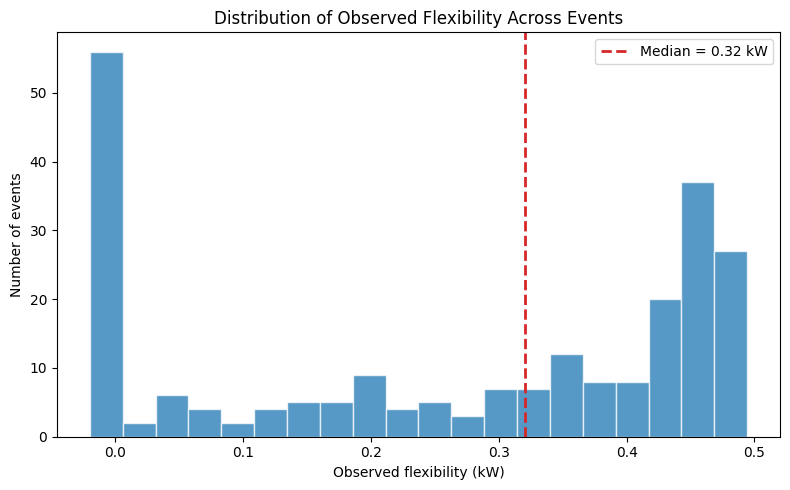

In [36]:
median_flex = event_validation_df['observed_flex_kW'].median()

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(event_validation_df['observed_flex_kW'], bins=20, color='tab:blue', alpha=0.75, edgecolor='white')
ax.axvline(median_flex, color='tab:red', linestyle='--', linewidth=2,
           label=f'Median = {median_flex:.2f} kW')

ax.set_xlabel('Observed flexibility (kW)')
ax.set_ylabel('Number of events')
ax.set_title('Distribution of Observed Flexibility Across Events')
ax.legend()

plt.tight_layout()
plt.show()

123 of 231 events had load exceeding flex (53.2%)


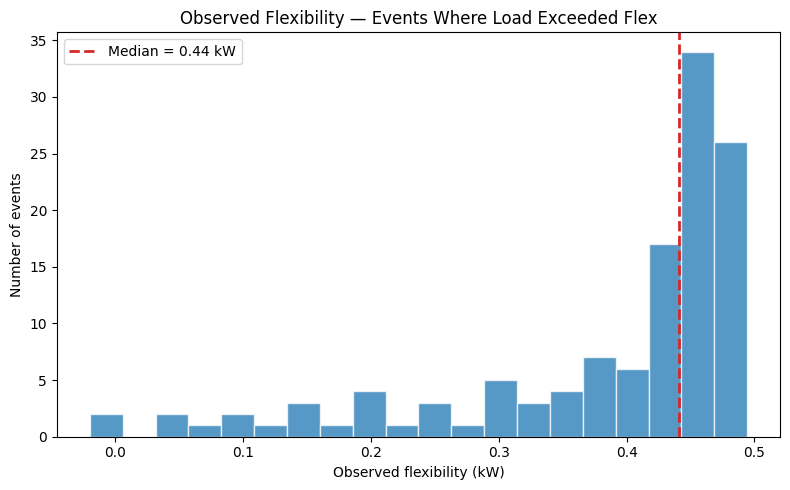

In [37]:
exceeded_df = event_validation_df[
    event_validation_df['observed_load_kW_mean'] > event_validation_df['observed_flex_kW']
]

print(f"{len(exceeded_df)} of {len(event_validation_df)} events had load exceeding flex "
      f"({len(exceeded_df) / len(event_validation_df) * 100:.1f}%)")

median_flex = exceeded_df['observed_flex_kW'].median()

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(exceeded_df['observed_flex_kW'], bins=20, color='tab:blue', alpha=0.75, edgecolor='white')
ax.axvline(median_flex, color='tab:red', linestyle='--', linewidth=2,
           label=f'Median = {median_flex:.2f} kW')

ax.set_xlabel('Observed flexibility (kW)')
ax.set_ylabel('Number of events')
ax.set_title('Observed Flexibility — Events Where Load Exceeded Flex')
ax.legend()

plt.tight_layout()
plt.show()

17 of 231 events dropped == 95% (7.4%)


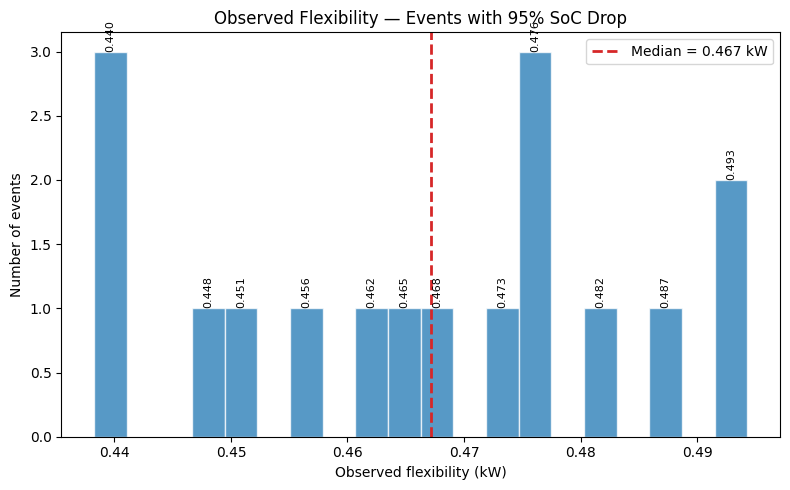

In [44]:
soc_drop = (
    observed_df.sort_values('timestamp')
    .groupby(['customer', 'battery_id', 'event'])['soc_pct']
    .agg(soc_start_pct='first', soc_end_pct='last')
    .reset_index()
)
soc_drop['pct_discharged'] = soc_drop['soc_start_pct'] - soc_drop['soc_end_pct']

# drop any existing pct_discharged first so re-running this cell is safe
event_validation_df = event_validation_df.drop(columns=['pct_discharged'], errors='ignore')

event_validation_df = event_validation_df.merge(
    soc_drop[['customer', 'battery_id', 'event', 'pct_discharged']],
    on=['customer', 'battery_id', 'event'],
    how='left'
)

# ---- filter to events where battery dropped == 95% ----
deep_discharge_df = event_validation_df[event_validation_df['pct_discharged'] == 95]

print(f"{len(deep_discharge_df)} of {len(event_validation_df)} events dropped == 95% "
      f"({len(deep_discharge_df) / len(event_validation_df) * 100:.1f}%)")

median_flex = deep_discharge_df['observed_flex_kW'].median()

fig, ax = plt.subplots(figsize=(8, 5))
counts, bin_edges, bars = ax.hist(deep_discharge_df['observed_flex_kW'], bins=20,
                                   color='tab:blue', alpha=0.75, edgecolor='white')

# label each non-empty bar with its bin center (x-axis value)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
for count, bar, center in zip(counts, bars, bin_centers):
    if count > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                 f'{center:.3f}', ha='center', va='bottom', fontsize=8, rotation=90)

ax.axvline(median_flex, color='tab:red', linestyle='--', linewidth=2,
           label=f'Median = {median_flex:.3f} kW')

ax.set_xlabel('Observed flexibility (kW)')
ax.set_ylabel('Number of events')
ax.set_title('Observed Flexibility — Events with 95% SoC Drop')
ax.legend()

plt.tight_layout()
plt.show()

### Validation w/ Averaged Loads

In [107]:
# ---- Step 3/4: predicted flex, two methods side by side ----
iE = ELITE_200V2_SPEC['inverter_efficiency']
batWh = ELITE_200V2_SPEC['battery_Wh']

dodFloor_event_Wh = batWh * (1 - LiFePOdod_event)
max_discharge_kW = ELITE_200V2_SPEC['inverter_W'] * 0.001

event_records = []

for (customer_num, battery_id, event_idx), g in observed_df.groupby(['customer', 'battery_id', 'event']):
    g = g.sort_values('timestamp').reset_index(drop=True)
    n_hours = len(g)

    observed_flex_kW = g['observed_flex_kW'].mean()
    observed_max_discharge_kW = g.loc[g['observed_flex_kW'] > 0, 'observed_flex_kW'].max()
    observed_load_kW_mean = g['observed_load_kW'].mean()
    observed_load_kW_max = g['observed_load_kW'].max()

    soc_start_pct = g.iloc[0]['soc_pct']
    batState_start_Wh = (soc_start_pct / 100.0) * batWh
    window_start_hour = int(g.iloc[0]['hour_of_day'])

    # Available capacity down to the event DoD floor, net of self-consumption
    # over the window, expressed as an average kW rate -- shared by both methods
    predicted_max_battery_flex_kW = (
        max(0.0, (batState_start_Wh - dodFloor_event_Wh) - powerStationSC * n_hours)
        * iE * 0.001 / n_hours
    )

    # ---- Method A: our hour-by-hour stepper (capacity + rate cap, tracked hourly) ----
    remaining_capacity_kWh = predicted_max_battery_flex_kW * n_hours
    for h in range(n_hours):
        served_kWh = min(g.iloc[h]['observed_load_kW'], max_discharge_kW)
        remaining_capacity_kWh = max(remaining_capacity_kWh - served_kWh, 0.0)
    predicted_flex_hourly_method_kW = (predicted_max_battery_flex_kW * n_hours - remaining_capacity_kWh) / n_hours

    # ---- Method B: the model's ACTUAL method (drFlexValue) -- single min(), no rate cap ----
    predicted_flex_model_method_kW = min(predicted_max_battery_flex_kW, observed_load_kW_mean)

    error_hourly_kW = predicted_flex_hourly_method_kW - observed_flex_kW
    error_model_kW = predicted_flex_model_method_kW - observed_flex_kW

    event_records.append({
        'customer': customer_num,
        'battery_id': battery_id,
        'event': event_idx,
        'window_start_hour': window_start_hour,
        'n_hours': n_hours,
        'soc_start_pct': soc_start_pct,
        'observed_flex_kW': observed_flex_kW,
        'observed_max_discharge_kW': observed_max_discharge_kW,
        'observed_load_kW_mean': observed_load_kW_mean,
        'observed_load_kW_max': observed_load_kW_max,
        'predicted_max_battery_flex_kW': predicted_max_battery_flex_kW,
        'predicted_flex_hourly_method_kW': predicted_flex_hourly_method_kW,
        'predicted_flex_model_method_kW': predicted_flex_model_method_kW,
        'error_hourly_kW': error_hourly_kW,
        'error_model_kW': error_model_kW,
    })

event_validation_df = pd.DataFrame(event_records)
print(f"Built {len(event_validation_df)} event-level predictions "
      f"for {event_validation_df['customer'].nunique()} households.")
event_validation_df.head(10)

Built 237 event-level predictions for 53 households.


,customer,battery_id,event,window_start_hour,n_hours,soc_start_pct,observed_flex_kW,observed_max_discharge_kW,observed_load_kW_mean,observed_load_kW_max,predicted_max_battery_flex_kW,predicted_flex_hourly_method_kW,predicted_flex_model_method_kW,error_hourly_kW,error_model_kW
0,1,1,1,16,4,97.066667,0.212008,0.459417,0.212008,0.459417,0.419972,0.212008,0.212008,0.000000e+00,0.000000
1,1,1,2,16,4,100.000000,0.153550,0.194083,0.169167,0.194083,0.433654,0.169167,0.169167,1.561667e-02,0.015617
2,1,1,3,16,4,98.666667,0.193342,0.210683,0.193342,0.210683,0.427435,0.193342,0.193342,-5.551115e-17,0.000000
3,3,1,1,16,4,100.000000,0.354971,0.443050,0.437883,0.608500,0.433654,0.433654,0.433654,7.868292e-02,0.078683
4,3,1,2,16,4,100.000000,0.381112,0.439300,0.426217,0.439300,0.433654,0.426217,0.426217,4.510417e-02,0.045104
5,3,1,3,16,4,94.333333,0.471462,0.678500,0.551625,0.678500,0.407223,0.407223,0.407223,-6.423950e-02,-0.064240
6,3,2,1,16,4,100.000000,0.475000,0.998467,0.885025,1.033150,0.433654,0.433654,0.433654,-4.134625e-02,-0.041346
7,3,2,2,16,4,100.000000,0.479358,0.586067,0.579546,0.596917,0.433654,0.433654,0.433654,-4.570458e-02,-0.045705
8,3,2,3,16,4,100.000000,0.481608,0.574567,0.520483,0.574567,0.433654,0.433654,0.433654,-4.795458e-02,-0.047955
9,4,1,1,16,4,100.000000,0.000000,NaN,0.000000,0.000000,0.433654,0.000000,0.000000,0.000000e+00,0.000000


In [16]:
event_validation_df.describe()

,customer,battery_id,event,window_start_hour,n_hours,soc_start_pct,soc_end_pct,pct_discharged,observed_flex_kW,observed_max_discharge_kW,observed_load_kW_mean,predicted_max_battery_flex_kW,predicted_actual_flex_kW,error_kW,accuracy_per
count,231.000000,231.000000,231.00000,231.000000,231.0,230.000000,231.000000,230.000000,231.000000,177.000000,231.000000,231.000000,229.000000,2.290000e+02,174.000000
mean,32.181818,1.350649,2.00000,15.272727,4.0,96.818551,51.772367,45.085435,0.263056,0.690368,0.429572,0.423330,0.257640,-4.389622e-03,0.993078
std,16.990325,0.529961,0.81827,1.579513,0.0,8.582577,37.857743,35.939909,0.190043,0.338114,0.409157,0.048766,0.180983,4.212989e-02,0.108452
min,1.000000,1.000000,1.00000,11.000000,4.0,26.666667,1.666667,0.000000,-0.019993,0.000417,0.000000,0.000000,0.000000,-7.600062e-02,0.697032
25%,19.000000,1.000000,1.00000,14.000000,4.0,97.333333,8.000000,2.000000,0.036498,0.451600,0.049085,0.426639,0.048867,-2.328860e-02,0.928189
50%,32.000000,1.000000,2.00000,16.000000,4.0,100.000000,49.200000,46.933333,0.320229,0.649283,0.360383,0.440010,0.342375,0.000000e+00,0.999888
75%,47.000000,2.000000,3.00000,16.000000,4.0,100.000000,97.000000,82.616667,0.444835,0.933600,0.671781,0.440010,0.426217,1.387779e-17,1.000000
max,60.000000,3.000000,3.00000,19.000000,4.0,100.000000,100.000000,95.000000,0.494312,1.628250,1.623092,0.440010,0.440010,4.600032e-01,1.601744


In [108]:
# ---- Focus on HIGH-LOAD events, where the battery is actually stress-tested ----
# Low-load events trivially "succeed" (predicted ~= observed ~= 0), which
# hides whatever real capacity error exists. Stratify by observed load to
# separate the easy cases from the meaningful ones.

load_threshold = event_validation_df['observed_load_kW_mean'].quantile(0.75)  # top quartile by load
high_load_df = event_validation_df[event_validation_df['observed_load_kW_mean'] >= load_threshold]

print(f"High-load threshold (75th percentile): {load_threshold:.3f} kW")
print(f"High-load events: {len(high_load_df)} / {len(event_validation_df)}\n")

for label, col in [('Hourly method (A)', 'error_hourly_kW'), ('Model method (B)', 'error_model_kW')]:
    all_mae = event_validation_df[col].abs().mean()
    high_mae = high_load_df[col].abs().mean()
    all_bias = event_validation_df[col].mean()
    high_bias = high_load_df[col].mean()
    print(f"{label}:")
    print(f"  All events   -> MAE: {all_mae:.4f} kW, bias: {all_bias:+.4f} kW")
    print(f"  High-load    -> MAE: {high_mae:.4f} kW, bias: {high_bias:+.4f} kW")
    print()

High-load threshold (75th percentile): 0.671 kW
High-load events: 60 / 237

Hourly method (A):
  All events   -> MAE: 0.0225 kW, bias: -0.0070 kW
  High-load    -> MAE: 0.0380 kW, bias: -0.0314 kW

Model method (B):
  All events   -> MAE: 0.0245 kW, bias: -0.0091 kW
  High-load    -> MAE: 0.0380 kW, bias: -0.0314 kW



In [ ]:
# Max event flex
# max sinlge-hour flex

## PV Performance Modeling

In [16]:
#get TMY via API
try:
    df_tmy, metadata = pvlib.iotools.get_nsrdb_psm4_tmy(
        latitude=lat,
        longitude=long,
        api_key=NREL_API_KEY,
        time_step=60,
        email='nathaa@rpi.edu',  # <-- any email works here fine
        year='tmy-2024')
except requests.HTTPError as e:
    print("Status code:", e.response.status_code)
    print("Raw response text:")
    print(e.response.text)
    raise

metadata

{'Source': 'NSRDB',
 'Location ID': '1243965',
 'City': '-',
 'State': '-',
 'Country': '-',
 'Time Zone': -5,
 'Local Time Zone': -5,
 'Clearsky DHI Units': 'w/m2',
 'Clearsky DNI Units': 'w/m2',
 'Clearsky GHI Units': 'w/m2',
 'Dew Point Units': 'c',
 'DHI Units': 'w/m2',
 'DNI Units': 'w/m2',
 'GHI Units': 'w/m2',
 'Solar Zenith Angle Units': 'Degree',
 'Temperature Units': 'c',
 'Pressure Units': 'mbar',
 'Relative Humidity Units': '%',
 'Precipitable Water Units': 'cm',
 'Wind Direction Units': 'Degrees',
 'Wind Speed Units': 'm/s',
 'Cloud Type -15': 'N/A',
 'Cloud Type 0': 'Clear',
 'Cloud Type 1': 'Probably Clear',
 'Cloud Type 2': 'Fog',
 'Cloud Type 3': 'Water',
 'Cloud Type 4': 'Super-Cooled Water',
 'Cloud Type 5': 'Mixed',
 'Cloud Type 6': 'Opaque Ice',
 'Cloud Type 7': 'Cirrus',
 'Cloud Type 8': 'Overlapping',
 'Cloud Type 9': 'Overshooting',
 'Cloud Type 10': 'Unknown',
 'Cloud Type 11': 'Dust',
 'Cloud Type 12': 'Smoke',
 'Fill Flag 0': 'N/A',
 'Fill Flag 1': 'Missing I

In [17]:
df_tmy.to_csv("data/tmy_2024_NYC.csv", index=True)

In [18]:
# make a Location object corresponding to this TMY
location = pvlib.location.Location(name='NYC',
                                   latitude=metadata['latitude'],
                                   longitude=metadata['longitude'])

location

Location: 
  name: NYC
  latitude: 40.73
  longitude: -74.02
  altitude: -2.0
  tz: UTC

In [19]:
#normalize all years to 2020
#remove timezone info #,tzinfo=None
df_tmy.index = df_tmy.index.map(lambda t: t.replace(year=2020))

#uncomment the 30 minute shifts if using data that is right-labeled at hourly intervals!
# Note: TMY datasets are right-labeled hourly intervals, e.g. the
# 10AM to 11AM interval is labeled 11.  We should calculate solar position in
# the middle of the interval (10:30), so we subtract 30 minutes:
times = df_tmy.index #- pd.Timedelta('30min')
solar_position = location.get_solarposition(times)
# but remember to shift the index back to line up with the TMY data:
#solar_position.index += pd.Timedelta('30min')

solar_position

,apparent_zenith,zenith,apparent_elevation,elevation,azimuth,equation_of_time
2020-01-01 00:30:00-05:00,161.167644,161.167644,-71.167644,-71.167644,22.397593,-3.190860
2020-01-01 01:30:00-05:00,154.001161,154.001161,-64.001161,-64.001161,54.029306,-3.210673
2020-01-01 02:30:00-05:00,143.834623,143.834623,-53.834623,-53.834623,72.365773,-3.230477
2020-01-01 03:30:00-05:00,132.705852,132.705852,-42.705852,-42.705852,84.714658,-3.250272
2020-01-01 04:30:00-05:00,121.355180,121.355180,-31.355180,-31.355180,94.580427,-3.270057
...,...,...,...,...,...,...
2020-12-31 19:30:00-05:00,121.549755,121.549755,-31.549755,-31.549755,265.621718,-3.441097
2020-12-31 20:30:00-05:00,132.896245,132.896245,-42.896245,-42.896245,275.528481,-3.460697
2020-12-31 21:30:00-05:00,144.009842,144.009842,-54.009842,-54.009842,287.965009,-3.480288
2020-12-31 22:30:00-05:00,154.134861,154.134861,-64.134861,-64.134861,306.489310,-3.499870


In [20]:
#get monthly temperature averages for validation
# for m in range(12):
#     df_tmy['Temperature']

In [21]:
# temperature coef
gamma_pdc = -0.003  # divide by 100 to go from %/°C to 1/°C

all_parameters = pvlib.temperature.TEMPERATURE_MODEL_PARAMETERS['sapm']
parameters = all_parameters['open_rack_glass_polymer']

#args: tilt, azimuth
def getPOA(t,a):
    #fixed tilt POA
    df_poa = pvlib.irradiance.get_total_irradiance(
        surface_tilt=t,
        surface_azimuth=a,
        dni=df_tmy['dni'],
        ghi=df_tmy['ghi'],
        dhi=df_tmy['dhi'],
        solar_zenith=solar_position['apparent_zenith'],
        solar_azimuth=solar_position['azimuth'],
        model='isotropic')

    #print(df_poa.keys())
    return df_poa

#DC power going in to battery after accounting for shading and equipment derating
#https://pvlib-python.readthedocs.io/en/stable/reference/generated/pvlib.pvsystem.pvwatts_dc.html#
#args: power, temp coefficient, array nameplate watts
def getPowerYield(p,g,n):
    
    # note the "splat" operator "**" which expands the dictionary "parameters"
    # into a comma separated list of keyword arguments
    cell_temperature = pvlib.temperature.sapm_cell(
        p['poa_global'], df_tmy['temp_air'], df_tmy['wind_speed'], **parameters)
    
    array_power = pd.DataFrame({
        'power': pvlib.pvsystem.pvwatts_dc(p['poa_global'], cell_temperature, n, g,temp_ref=25.0)
    })

    #yieldDC is actual power going in to battery after losses
    array_power['yieldDC'] = array_power['power'] * shading * mppt

    #yieldAC is actual power going in to grid after losses
    array_power['yieldAC'] = array_power['power'] * shading * miEff
    
    return array_power
    #array_power = pvlib.pvsystem.pvwatts_dc(df_poa['poa_global'], cell_temperature, n, g,temp_ref=25.0)

    #factor in 14% shading losses + 1% mppt losses
    #return array_power * shading * mppt

# #convert DC to AC with PV Watts model
# #https://pvlib-python.readthedocs.io/en/stable/reference/generated/pvlib.inverter.pvwatts.html#pvlib.inverter.pvwatts
# #args: dc power input to inverter, inverter nameplate max WAC output, nameplate efficiency


#returns the degraded power of the array for a given year
#args: PV watts, year, PV degradation rate
def getDegradedP(w,y,dR = DEG_RATE):
    d = 1 - dR
    return w*(d**y)

array_power_yield = getPowerYield(getPOA(tilt,azimuth),gamma_pdc, 100)
array_power_yield.head()

,power,yieldDC,yieldAC
2020-01-01 00:30:00-05:00,0.0,0.0,0.0
2020-01-01 01:30:00-05:00,0.0,0.0,0.0
2020-01-01 02:30:00-05:00,0.0,0.0,0.0
2020-01-01 03:30:00-05:00,0.0,0.0,0.0
2020-01-01 04:30:00-05:00,0.0,0.0,0.0


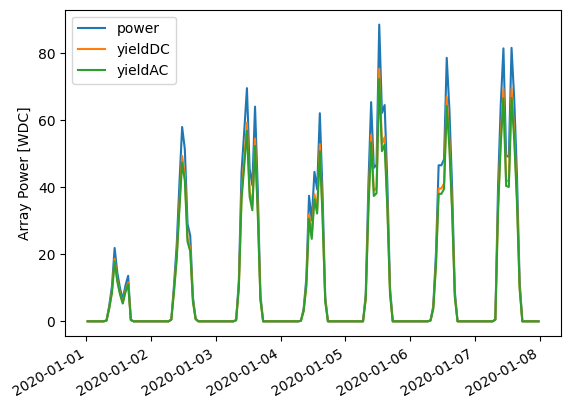

In [22]:
array_power_yield.head(24*7).plot()
plt.ylabel('Array Power [WDC]');

In [23]:
# this function gets yield data for a range of things
def getYieldData(tilt=tilt, gamma_pdc=gamma_pdc, maxPV=pvMaxW, pvInc=50, azimuths=(110, 180, 250)):
    """
    Get hourly and daily PV yields for all possible array sizes being modeled,
    at each of the given azimuths.

    Args:
        tilt (float): array tilt angle (degrees).
        gamma_pdc (float): PV temperature coefficient (1/°C).
        maxPV (int): max allowed PV nameplate wattage of any power station
                     in the database (default 1200).
        pvInc (int): increment (W) to step through array sizes (default 50).
        azimuths (iterable of int): azimuth angles to model (default (110, 180, 250)).

    Returns:
        dict: {
            '<azimuth>': {
                '<pW>': {
                    'hourly': <DataFrame from getPowerYield>,
                    'daily': {'dailyDC': [...], 'dailyAC': [...]}
                },
                ...
            },
            ...
        }
    """
    yieldData = {str(a): {} for a in azimuths}

    #print(f'Max PV: {maxPV}')

    for a in azimuths:
        poa = getPOA(tilt, a)

        aData = {}
        for pW in range(pvInc, maxPV + pvInc, pvInc):
            # get hourly power yields for a given array size (W)
            hY = getPowerYield(poa, gamma_pdc, pW)

            # get daily PV yields (Wh)
            # dYDC = []
            # dYAC = []
            # for d in range(365):
            #     dYDC.append(hY['yieldDC'].iloc[d*24:(d*24)+24].sum())
            #     dYAC.append(hY['yieldAC'].iloc[d*24:(d*24)+24].sum())
            dYDC = hY['yieldDC'].to_numpy().reshape(365, 24).sum(axis=1)
            dYAC = hY['yieldAC'].to_numpy().reshape(365, 24).sum(axis=1)

            aData[str(pW)] = {
                'hourly': hY,
                'daily': {'dailyDC': dYDC, 'dailyAC': dYAC}
            }

        yieldData[str(a)] = aData

    return yieldData
    

In [24]:
yieldData = getYieldData()

# Annual Energy Modeling

battery is only charged from the grid when an event is upcoming. This considers average solar in July

In [25]:
def pv_to_stored_charge(pv_w, plugin, acToDC):
    """Energy reaching the battery as stored charge, after conversion losses.
    plugin=True: pv_w is already AC (post-microinverter) -> battery charger (acToDC).
    plugin=False: pv_w is DC -> straight into battery, no conversion loss."""
    return pv_w * acToDC if plugin else pv_w

def battery_to_load(load_wac, iE):
    """AC load converted into the DC draw required from the battery
    (battery inverter, discharge side)."""
    return load_wac / iE

In [26]:
def simulate_hourly_energy(pvYieldW, batWh, loadWAC, iE, y: int = 0, plugin=True,
                            dailySelfConsumptionWhDC=dailySelfConsumptionWhDC,
                            LiFePOdod=LiFePOdod, acToDC=acToDC,
                            chargeTargetFraction=0.8,
                            drWindowStartHour=None,
                            maxChargeRateW=1800, maxDischargeRateW=None):
    """
    Step through a year hour-by-hour, simulating a charge/discharge cycle
    capped at once per calendar day, with any grid-sourced charging capped
    at maxChargeRateW (Wh/hour, AC-side) rather than applied instantly --
    the number of hours it takes depends on how large the gap is.

    loadWAC may be either a scalar (constant load every hour, the original
    behavior) or an array-like of length len(pvYieldW) giving an hourly
    load profile -- e.g. a load that's only "on" during certain months
    (see build_seasonal_load_array). Internally it's always expanded to a
    per-hour array so seasonal and constant loads are handled identically.

    OFF-GRID discharge triggers: either the battery reaches chargeTarget
    (80%) after 3pm on a day the cycle hasn't been used yet, OR projected
    overflow risk (reserving multi-hour headroom based on the trailing
    week's peak PV hour vs. load size) forces an early discharge to avoid
    curtailing PV, regardless of time or the daily cap. If discharge was
    triggered by overflow risk specifically, it reverts back to 'charging'
    as soon as that risk resolves (rather than waiting for the DoD floor),
    and frees the daily cycle back up so a normal 80%-target discharge can
    still happen later that day if conditions call for it.

    maxChargeRateW / maxDischargeRateW: AC-side hardware power caps
    (Wh/hour) that apply ONLY to grid-sourced battery charging and to
    battery discharge that serves the load -- NOT to PV-to-battery
    charging, which is left uncapped. This models something like a charger
    or inverter's rated AC power limit rather than the battery cell's own
    charge/discharge limit. Because they're AC-side, they're converted
    through acToDC / iE before being compared against the DC-side battery
    flows used internally:
      - charging: capped in DC terms as maxChargeRateW * acToDC, so the
        resulting AC grid draw (chargeAmount / acToDC) never exceeds
        maxChargeRateW. Defaults to 1800 (a typical charger AC power
        rating).
      - discharging: capped in DC terms as maxDischargeRateW / iE, so the
        resulting AC output to the load (servedWDC * iE) never exceeds
        maxDischargeRateW. Defaults to None (no cap).
    Each cap is enforced independently at each grid-charge / discharge-to-load
    point rather than as a single combined per-hour budget.

    PLUG-IN pre-event solar charging: during the DR season, in the hours
    before each day's grid window opens, any surplus PV (beyond what's
    needed to serve the load) is used to charge the battery -- but only up
    to batWh minus a reserve, rather than straight to full. The reserve
    equals the largest total PV the grid window itself pulled toward the
    battery on any of the last 7 event-days (tracked as the simulation
    steps forward, so it only ever looks at past event-days, never today's
    own window). This way the battery goes into the event already
    well-charged, while still leaving enough headroom that the window's
    own PV production isn't curtailed once the event starts.
    """

    #battery start state
    startState=0.5
    
    # DR season info
    seasonStartDay = drSeasonStartDay
    seasonDays = daysInMonth

    # DR window
    drWindowLengthHours = 4
    drWindowEndHour = None
    
    if drWindowStartHour is not None:
        drWindowEndHour = drWindowStartHour + drWindowLengthHours

    # the grid window only applies during the DR season (e.g. May-Sep);
    # outside the season it behaves as if drWindowStartHour were None
    seasonStartHour = (seasonStartDay - 1) * 24
    seasonEndHour = seasonStartHour + (sum(seasonDays) * 24)  # exclusive

    n = len(pvYieldW)

    # expand loadWAC to a per-hour array so scalar and seasonal/array loads
    # are handled by the exact same code path below
    loadWAC_arr = np.full(n, loadWAC, dtype=float) if np.isscalar(loadWAC) else np.asarray(loadWAC, dtype=float)
    if len(loadWAC_arr) != n:
        raise ValueError(f'loadWAC array length ({len(loadWAC_arr)}) must match pvYieldW length ({n})')
    loadWDC_arr = battery_to_load(loadWAC_arr, iE)

    dodFloor = batWh * (1 - LiFePOdod)
    chargeTarget = batWh * chargeTargetFraction
    hourlyScWDC = dailySelfConsumptionWhDC / 24

    # AC-side hardware caps, converted to the DC-side units used internally.
    # None -> effectively unlimited. Only applied to grid charging and to
    # battery discharge that serves the load -- PV charging is uncapped.
    chargeCapW_DC = (maxChargeRateW * acToDC) if maxChargeRateW is not None else float('inf')
    dischargeCapW_DC = (maxDischargeRateW / iE) if maxDischargeRateW is not None else float('inf')

    batState_arr = np.empty(n)
    surplus_arr = np.zeros(n)
    avoided_arr = np.zeros(n)
    required_arr = np.zeros(n)
    grid_to_load_arr = np.zeros(n)
    grid_battery_charge_arr = np.zeros(n)

    batState = batWh * startState
    mode = 'charging'
    dischargeCycleUsedToday = False
    rechargeCycleUsedToday = False
    dischargingDueToOverflow = False   # off-grid: tracks whether the current discharge was overflow-triggered

    floorCharging = False
    rechargingFromGrid = False

    pvHistory = deque(maxlen=168)

    # trailing week of event-day totals for the plug-in pre-event solar
    # charging reserve -- see docstring
    windowPVHistory = deque(maxlen=7)
    windowPVAccumDC = 0.0

    dischargeHour = 20 if drWindowEndHour is None else drWindowEndHour
    dischargeEndHour = 6 

    for i, h in enumerate(pvYieldW):
        hourOfDay = i % 24
        if hourOfDay == 0:
            dischargeCycleUsedToday = False
            rechargeCycleUsedToday = False

        pv_w = getDegradedP(h, y)  # PV is already AC if plugin, else it is DC
        loadWAC = loadWAC_arr[i]
        loadWDC = loadWDC_arr[i]

        # check if this hour is within the DR window
        inSeason = seasonStartHour <= i < seasonEndHour
        inDRWindow = (
            drWindowEndHour is not None
            and inSeason
            and drWindowStartHour <= hourOfDay < drWindowEndHour
        )

        if not plugin:
            # ---------------- OFF-GRID ----------------
            stored = pv_w
            batState += stored - hourlyScWDC   # PV always charges simultaneously, regardless of mode; uncapped
            pvHistory.append(stored)

            maxHourlyPVPastWeek = max(pvHistory) if pvHistory else stored
            denom = loadWDC if loadWDC > 0 else 1e-6
            reserve = min(maxHourlyPVPastWeek * (maxHourlyPVPastWeek / denom), batWh)
            wouldOverflow = (batState + reserve) > batWh
            hourOfDay = i % 24

            if mode == 'charging':
                reachedTarget = batState >= chargeTarget
                if wouldOverflow or (reachedTarget and not dischargeCycleUsedToday and hourOfDay >= dischargeHour):
                    mode = 'discharging'
                    dischargeCycleUsedToday = True
                    dischargingDueToOverflow = wouldOverflow
            elif mode == 'discharging':
                if dischargingDueToOverflow and not wouldOverflow:
                    mode = 'charging'
                    dischargeCycleUsedToday = False  # frees the cycle back up for a later 3pm+ discharge
                    dischargingDueToOverflow = False
                elif not dischargingDueToOverflow and hourOfDay == dischargeEndHour:
                    # cap the nightly discharge-to-load window at the early-morning
                    # cutoff even if the DoD floor hasn't been reached yet; overflow-
                    # triggered discharge is exempt and keeps running until it resolves
                    mode = 'charging'

            if mode == 'charging':
                avoided_arr[i] = 0.0
                grid_to_load_arr[i] = loadWAC
            else:  # discharging (serves the load -- AC-side discharge cap applies here)
                if inDRWindow:
                    # grid window: never discharge the battery to serve the
                    # load, even if a discharge cycle is already underway
                    if dischargingDueToOverflow:
                        # still avoid curtailing/wasting PV even during the window,
                        # but only pull the minimum needed to prevent overflow --
                        # never a full load-serving discharge
                        overflowAmount = max(0.0, batState - batWh)
                        availableWDC = max(0.0, batState - dodFloor)
                        servedWDC = min(overflowAmount, availableWDC, loadWDC)
                        if servedWDC > dischargeCapW_DC:
                            # load exceeds the power station's max discharge rate --
                            # don't serve a partial amount, put it all on the grid instead
                            servedWDC = 0.0
                    else:
                        # grid window: never voluntarily discharge to serve the load
                        servedWDC = 0.0
                elif hourOfDay >= dischargeHour or hourOfDay < dischargeEndHour:
                    # after the set discharge time: draw as much as the load needs, normal cycling behavior
                    availableWDC = max(0.0, batState - dodFloor)
                    servedWDC = min(loadWDC, availableWDC)
                    if servedWDC > dischargeCapW_DC:
                        # load exceeds the power station's max discharge rate --
                        # don't serve a partial amount, put it all on the grid instead
                        servedWDC = 0.0
                else:
                    # before the set discharge time: only pull what's needed to avoid exceeding capacity
                    overflowAmount = max(0.0, batState - batWh)
                    availableWDC = max(0.0, batState - dodFloor)
                    servedWDC = min(overflowAmount, availableWDC, loadWDC)
                    if servedWDC > dischargeCapW_DC:
                        # load exceeds the power station's max discharge rate --
                        # don't serve a partial amount, put it all on the grid instead
                        servedWDC = 0.0

                batState -= servedWDC
                avoided_arr[i] = servedWDC * iE
                grid_to_load_arr[i] = loadWAC - avoided_arr[i]

            # DoD floor safety net, rate-capped instead of instant (grid-sourced -- AC-side charge cap applies)
            if batState < dodFloor:
                floorCharging = True
            if floorCharging:
                gap = dodFloor - batState
                chargeAmount = min(gap, chargeCapW_DC)
                batState += chargeAmount
                required_arr[i] = chargeAmount / acToDC
                if batState >= dodFloor:
                    floorCharging = False

            # capacity safety net -- true curtailment, should be rare given the overflow check above
            if batState > batWh:
                sur = batState - batWh
                surplus_arr[i] = sur * iE
                batState = batWh

            # reaching the DoD floor always ends a discharge cycle, overflow-triggered or not
            if mode == 'discharging' and batState <= dodFloor:
                mode = 'charging'
                dischargingDueToOverflow = False

        else:
            # ---------------- PLUG-IN ----------------
            pv_avail_AC = pv_w  # already AC (microinverter output)

            if inDRWindow:
                # grid window: grid fully serves the load; any available PV
                # is redirected to charge the battery instead of the load
                avoided_arr[i] = 0.0
                grid_to_load_arr[i] = loadWAC

                # PV -> battery charging: uncapped (not a grid-sourced charge)
                pv_to_batt_DC = pv_to_stored_charge(pv_avail_AC, True, acToDC)
                windowPVAccumDC += pv_to_batt_DC  # this event-day's running window PV total
                room_DC = max(0.0, batWh - batState)
                chargeAmount_DC = min(pv_to_batt_DC, room_DC)
                batState += chargeAmount_DC
                grid_battery_charge_arr[i] = 0.0  # this charge comes from PV, not the grid
                # any PV that couldn't be stored is curtailed/exported
                storedAsPV_AC = chargeAmount_DC / acToDC if acToDC else 0.0
                surplus_arr[i] = max(0.0, pv_avail_AC - storedAsPV_AC)

                if hourOfDay == drWindowEndHour - 1:
                    # window just closed for the day -- bank today's total so
                    # future pre-event charging can reserve room for it
                    windowPVHistory.append(windowPVAccumDC)
                    windowPVAccumDC = 0.0
            else:
                servedByPV_AC = min(loadWAC, pv_avail_AC)
                avoided_arr[i] = servedByPV_AC  # PV directly serving load is avoided grid draw
                remainingLoad_AC = loadWAC - servedByPV_AC
                surplus = pv_avail_AC - servedByPV_AC

                canDischargeForLoad = hourOfDay >= dischargeHour

                if rechargingFromGrid:
                    # grid-sourced charging -- AC-side charge cap applies
                    gap = chargeTarget - batState
                    chargeAmount = min(gap, chargeCapW_DC)
                    batState += chargeAmount
                    chargeAmtAC = chargeAmount / acToDC
                    usefulOutputAC = chargeAmount * iE
                    surplus_arr[i] = max(0, surplus - chargeAmtAC)
                    grid_battery_charge_arr[i] = chargeAmtAC
                    required_arr[i] = chargeAmtAC - usefulOutputAC
                    grid_to_load_arr[i] = remainingLoad_AC
                    if batState >= chargeTarget:
                        rechargingFromGrid = False
                else:
                    if canDischargeForLoad:
                        surplus_arr[i] = surplus
                        # discharge serving the load -- AC-side discharge cap applies
                        remainingLoadWDC = remainingLoad_AC / iE
                        availableWDC = max(0.0, batState - dodFloor)
                        servedWDC = min(remainingLoadWDC, availableWDC)
                        if servedWDC > dischargeCapW_DC:
                            # load exceeds the power station's max discharge rate --
                            # don't serve a partial amount, put it all on the grid instead
                            servedWDC = 0.0
                        batState -= servedWDC
                        grid_to_load_arr[i] = remainingLoad_AC - (servedWDC * iE)
                    else:
                        # before the event window (or off-season / no window
                        # configured): use surplus solar to pre-charge the
                        # battery ahead of the event, but leave headroom for
                        # the window's own expected PV (see windowPVHistory
                        # in the docstring) so it isn't curtailed once the
                        # event starts
                        if inSeason and drWindowStartHour is not None and surplus > 0:
                            windowPVReserveWDC = max(windowPVHistory) if windowPVHistory else 0.0
                            target_DC = max(0.0, batWh - windowPVReserveWDC)
                            room_DC = max(0.0, target_DC - batState)
                            pv_to_batt_DC = pv_to_stored_charge(surplus, True, acToDC)
                            chargeAmount_DC = min(pv_to_batt_DC, room_DC)
                            batState += chargeAmount_DC
                            storedAsPV_AC = chargeAmount_DC / acToDC if acToDC else 0.0
                            surplus_arr[i] = max(0.0, surplus - storedAsPV_AC)
                        else:
                            surplus_arr[i] = surplus
                        # grid covers whatever PV (directly, or after pre-charging) didn't
                        grid_to_load_arr[i] = remainingLoad_AC

            batState -= hourlyScWDC

            # keep the battery above DoD
            if not rechargingFromGrid and batState < dodFloor:
                topOff = dodFloor - max(batState, 0)
                required_arr[i] += topOff / acToDC
                batState = dodFloor

            if batState <= dodFloor and not rechargeCycleUsedToday and not rechargingFromGrid:
                rechargingFromGrid = True
                rechargeCycleUsedToday = True

        batState_arr[i] = batState

    return {
        'batState': batState_arr,
        'surplusWhAC': surplus_arr,
        'avoidedGridWhAC': avoided_arr,
        'requiredGridWhAC': required_arr,
        'grid_to_loadWhAC': grid_to_load_arr,
        'gridBatteryChargeWhAC': grid_battery_charge_arr,
    }

In [27]:
# depreciated, but keep anyway
def build_seasonal_load_array(loadW, n_hours=None,
                               season_start_day=drSeasonStartDay,
                               season_days=daysInMonth):
    """
    Build an hourly load array for a full year (or n_hours, if given).

    seasonal=False: load is constant, on all year round (e.g. a fridge --
    always drawing power, so PV/battery should offset it every month).
    seasonal=True: load is only "on" during the DR season (by default May 1
    through Sep 30, i.e. day season_start_day through
    season_start_day + sum(season_days) - 1) and zero the rest of the year
    (e.g. an AC unit that isn't in use outside the DR season).

    Returns a numpy array of length n_hours (default 365*24 = 8760).
    """
    if n_hours is None:
        n_hours = 365 * 24

    # if loadW is already an array (not a single number), just return
    # it as-is instead of broadcasting it as a constant.
    if not np.isscalar(loadW):
        arr = np.asarray(loadW, dtype=float)
        if len(arr) != n_hours:
            raise ValueError(
                f"loadW array length ({len(arr)}) must match n_hours ({n_hours})"
            )
        return arr

    season_len_days = sum(season_days)
    season_start_hour = (season_start_day - 1) * 24
    season_end_hour = season_start_hour + (season_len_days * 24)  # exclusive

    arr = np.zeros(n_hours, dtype=float)
    lo = max(0, season_start_hour)
    hi = min(n_hours, season_end_hour)
    if lo < hi:
        arr[lo:hi] = loadW
    return arr

In [74]:
# Load the ResStock load data (average across the unique NYC multifamily buildings

ac_path = max(glob.glob("data/ResStock_loads/ac_hourly_W_with_average_and_medoid_*.csv"))
print("Using AC file:", ac_path)

fridge_path = max(glob.glob("data/ResStock_loads/fridge_hourly_W_with_average_and_medoid_*.csv"))
print("Using fridge file:", fridge_path)


ac_df = pd.read_csv(ac_path, index_col=0, parse_dates=True)
ac_hourly_W = ac_df["average"].to_numpy()

fridge_df = pd.read_csv(fridge_path, index_col=0, parse_dates=True)
fridge_hourly_W = fridge_df["average"].to_numpy()

# just needed to match the length
hourly_array_power_yield_test=yieldData[str(180)]['100']['hourly']['yieldAC']

n_hours_model = len(hourly_array_power_yield_test)  # match whichever variable your loop actually uses
assert len(fridge_hourly_W) == n_hours_model, (
    f"fridge array length ({len(fridge_hourly_W)}) != model hours ({n_hours_model})"
)

assert len(ac_hourly_W) == n_hours_model, (
    f"ac array length ({len(ac_hourly_W)}) != model hours ({n_hours_model})"
)

loads = {
    'loadOneW': ac_hourly_W,        # AC — ResStock hourly profile (avg of unique buildings)
    'loadTwoW': fridge_hourly_W,   # fridge — ResStock hourly profile (avg of unique buildings)
    'loadOneW_Replacement': ac_hourly_W,    # fan — still fixed, unchanged for now
}

FAN_REPLACEMENT_W = 75  # only used as drFlexValue's replacement_kW, never as an hourly array
loadOneReplacement_kW = FAN_REPLACEMENT_W * .001

# minus 2 to ignore the mean and medoid columns in the data
print(f"Fridge array: {fridge_df.shape[1] - 2} buildings averaged, "
      f"annual mean {fridge_hourly_W.mean():.1f} W, peak {fridge_hourly_W.max():.1f} W")

print(f"AC array: {ac_df.shape[1] - 2} buildings averaged, "
      f"annual mean {ac_hourly_W.mean():.1f} W, peak {ac_hourly_W.max():.1f} W")

Using AC file: data/ResStock_loads\ac_hourly_W_with_average_and_medoid_20260724_173230.csv
Using fridge file: data/ResStock_loads\fridge_hourly_W_with_average_and_medoid_20260724_173230.csv
Fridge array: 7 buildings averaged, annual mean 88.5 W, peak 114.9 W
AC array: 100 buildings averaged, annual mean 93.8 W, peak 549.2 W


In [73]:
# returns the sum of all energy consumed by the load in a year
def annual_total_kWh(hourly_W, n_hours=8760):
    """
    True annual total energy (kWh AC) for a load.

    hourly_W may be a scalar (original behavior: assumes n_hours of
    constant draw) or an array-like of real hourly values, in which case
    it's summed directly rather than reconstructed from an average --
    exact regardless of the array's actual length, instead of relying on
    a hardcoded 8760 lining up with a separately-computed mean.
    """
    if np.isscalar(hourly_W):
        return hourly_W * n_hours * 0.001
    return np.asarray(hourly_W, dtype=float).sum() * 0.001

In [32]:
def event_window_max(hourly_W, window_start_hour, window_length_hours=4,
                       season_start_day=drSeasonStartDay, season_days=daysInMonth):
    """
    Max hourly W during the DR event window (window_start_hour through
    window_start_hour + window_length_hours), computed separately for
    each month of the DR season (season_start_day through
    season_start_day + sum(season_days) - 1)

    hourly_W may be a scalar (returns [hourly_W] * n_months, a safe
    no-op for loads that haven't been switched to real hourly data yet,
    e.g. loadOneW_Replacement) or an array-like of length n_hours.

    Returns a list of length len(season_days), one mean per DR-season
    month in season order (e.g. [May, Jun, Jul, Aug, Sep]).

    Use this instead of a single aggregate mean anywhere a value needs
    to reflect what the load actually looks like during a called
    event in a specific month.
    """
    n_months = len(season_days)

    if np.isscalar(hourly_W):
        return [hourly_W] * n_months

    arr = np.asarray(hourly_W, dtype=float)
    n_hours = len(arr)
    hour_of_day = np.arange(n_hours) % 24
    day_of_year = np.arange(n_hours) // 24 + 1

    in_window = (hour_of_day >= window_start_hour) & (hour_of_day < window_start_hour + window_length_hours)

    monthly_maxs = []
    month_start_day = season_start_day
    for month_len in season_days:
        month_end_day = month_start_day + month_len  # exclusive
        in_month = (day_of_year >= month_start_day) & (day_of_year < month_end_day)
        mask = in_month & in_window
        if not mask.any():
            raise ValueError(
                f"Event window mask matched zero hours for month starting day "
                f"{month_start_day} — check window_start_hour/season params"
            )
        monthly_maxs.append(arr[mask].max())
        month_start_day = month_end_day

    return monthly_maxs

## Plots to check energy analysis is working as expected

In [41]:
pvW = 600
hourly_array_power_yield_test=yieldData[str(180)][str(pvW)]['hourly']['yieldAC']
#hourly_array_power_yield_test = np.asarray([0] * 365 * 24)

batWh = 1000
#loadWACnominal = 1000
#loadWAC = build_seasonal_load_array(loadWACnominal, seasonal=False, n_hours=len(hourly_array_power_yield_test))
loadWAC=loads["loadOneW"]
loadName = 'ac'
iE = .85
y = 0
plugin = False

drWindowStartHour = 16

window_start = '2025-04-15'
window_end = '2025-5-15'

g = simulate_hourly_energy(list(hourly_array_power_yield_test), batWh, loadWAC, iE, y, plugin,drWindowStartHour=drWindowStartHour,maxChargeRateW=1800,maxDischargeRateW=800)

In [18]:
# pv_production_arr = np.array([
#     pv_to_stored_charge(getDegradedP(h, y), plugin, acToDC)
#     for h in hourly_array_power_yield_test
# ])
# idx = pd.date_range('2025-01-01', periods=len(g['batState']), freq='h')
# df = pd.DataFrame(g, index=idx)
# df['pvProductionWh'] = pv_production_arr
# df['loadWAC'] = loadWAC
# df['batteryDischargeToLoadWhAC'] = df['loadWAC'] - df['avoidedGridWhAC'] - df['grid_to_loadWhAC']
# dodFloor = batWh * (1 - LiFePOdod)

# # recreate the grid-window + DR-season mask the simulation used, so we can
# # shade it on the plots (drWindowLengthHours must match the value
# # hardcoded inside simulate_hourly_energy)
# drWindowLengthHours = 4
# hourOfDay = df.index.hour
# dayOfYear = df.index.dayofyear
# seasonEndDay = drSeasonStartDay + sum(daysInMonth) - 1
# inSeason = (dayOfYear >= drSeasonStartDay) & (dayOfYear <= seasonEndDay)
# inWindow = (
#     (drWindowStartHour is not None)
#     & (hourOfDay >= (drWindowStartHour or 0))
#     & (hourOfDay < (drWindowStartHour or 0) + drWindowLengthHours)
# )
# df['inDRWindow'] = inSeason & inWindow

# # zoom window -- 4 days
# window = df.loc[window_start:window_end]

# def get_event_spans(mask):
#     """Collapse a boolean hourly Series into a list of (start, end) timestamp
#     spans, so contiguous event hours become a single shaded block."""
#     spans = []
#     in_span = False
#     start = None
#     vals = mask.values
#     times = mask.index
#     for i in range(len(vals)):
#         if vals[i] and not in_span:
#             start = times[i]
#             in_span = True
#         elif not vals[i] and in_span:
#             spans.append((start, times[i]))
#             in_span = False
#     if in_span:
#         spans.append((start, times[-1] + pd.Timedelta(hours=1)))
#     return spans

# event_spans = get_event_spans(window['inDRWindow'])

# fig, axes = plt.subplots(6, 1, figsize=(14, 13), sharex=True)

# axes[0].fill_between(window.index, window['pvProductionWh'], color='tab:purple', alpha=0.6, linewidth=0)
# axes[0].set_ylabel('PV Production (Wh)')
# axes[0].set_title('PV Production, After Losses — Hourly')

# axes[1].plot(window.index, window['batState'], linewidth=1.5, color='tab:blue')
# axes[1].axhline(batWh, color='gray', linestyle='--', linewidth=1, label='Battery capacity')
# axes[1].axhline(dodFloor, color='firebrick', linestyle='--', linewidth=1, label='DoD floor')
# axes[1].set_ylabel('Battery State (Wh)')
# axes[1].set_title('Battery State of Charge — Hourly')

# axes[2].fill_between(window.index, window['surplusWhAC'], color='tab:green', alpha=0.6, linewidth=0)
# axes[2].set_ylabel('Surplus (Wh AC)')
# axes[2].set_title('Curtailed / Surplus Energy — Hourly (Unused PV)')

# axes[3].fill_between(window.index, window['avoidedGridWhAC'], color='tab:orange', alpha=0.6, linewidth=0, label='Avoided Grid')
# axes[3].plot(window.index, window['loadWAC'], color='tab:brown', linestyle='--', linewidth=1, label='Energy Demand (load)')
# axes[3].set_ylabel('Wh AC')
# axes[3].set_title('Grid Draw Avoided — Hourly (PV to load)')

# axes[4].fill_between(window.index, window['requiredGridWhAC'], color='tab:red', alpha=0.6, linewidth=0)
# axes[4].set_ylabel('Required Grid (Wh AC)')
# axes[4].set_title('Grid Draw Required — Hourly (Additional energy demand from grid to battery)')
# axes[4].set_xlabel('Date')

# axes[5].stackplot(
#     window.index,
#     window['grid_to_loadWhAC'],
#     window['batteryDischargeToLoadWhAC'],
#     colors=['tab:brown', 'tab:blue'],
#     alpha=0.6,
#     labels=['Grid to Load (direct)', 'Battery Discharge to Load (grid-sourced)'],
# )
# axes[5].plot(window.index, window['loadWAC'], color='black', linestyle=':', linewidth=1, label='Energy Demand (load)')
# axes[5].set_ylabel('Wh AC')
# axes[5].set_title('Grid Draw to Load — Hourly (Direct + Battery-Mediated)')
# axes[5].set_xlabel('Date')

# # shade the DR event window on every panel
# for ax_i, ax in enumerate(axes):
#     for span_i, (span_start, span_end) in enumerate(event_spans):
#         ax.axvspan(
#             span_start, span_end,
#             color='gold', alpha=0.25, zorder=0,
#             label='DR Event Window (grid-powered)' if (ax_i in (1, 3, 5) and span_i == 0) else None,
#         )

# # vertical lines every 6 hours, across all panels, to align comparison
# gridlines = pd.date_range(window.index[0].normalize(), window.index[-1] + pd.Timedelta(hours=1), freq='6h')
# for ax in axes:
#     for t in gridlines:
#         ax.axvline(t, color='gray', linestyle=':', linewidth=0.8, alpha=0.5)

# # re-issue legends now that the shaded-span label has been added
# for ax in (axes[1], axes[3], axes[5]):
#     ax.legend(loc='upper right', fontsize=8)

# fig.suptitle(f'Battery System Overview — {window_start} to {window_end}', fontsize=16, fontweight='bold')
# plt.tight_layout()
# timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
# plt.savefig(f'outputs/tests/battery_system_overview_{window_start}_{window_end}_{plugin}_{timestamp}.png', dpi=300, bbox_inches='tight')
# plt.show()

### Plot used in paper to demonstrate control scheme

In [17]:
# # 4-subplot overview: Off-grid vs Plug-in, Mid-July vs Mid-January (1-week windows each)

# week_windows = {
#     'Mid-July': ('2025-07-15', '2025-07-22'),
#     'Mid-January': ('2025-01-15', '2025-01-22'),
# }
# plugin_configs = [('Off-grid', False), ('Plug-in', True)]

# fig, axes2 = plt.subplots(2, 2, figsize=(20, 10), sharex='col')

# for row, (config_label, config_plugin) in enumerate(plugin_configs):
#     g2 = simulate_hourly_energy(
#         list(hourly_array_power_yield_test), batWh, loadWAC, iE, y, config_plugin,
#         drWindowStartHour=drWindowStartHour,maxDischargeRateW=600
#     )
#     pv_production_arr2 = np.array([
#         pv_to_stored_charge(getDegradedP(h, y), config_plugin, acToDC)
#         for h in hourly_array_power_yield_test
#     ])
#     idx2 = pd.date_range('2025-01-01', periods=len(g2['batState']), freq='h')
#     df2 = pd.DataFrame(g2, index=idx2)
#     df2['pvProductionWh'] = pv_production_arr2
#     df2['loadWAC'] = loadWAC

#     # recreate the grid-window + DR-season mask, same logic as the cell above
#     hourOfDay2 = df2.index.hour
#     dayOfYear2 = df2.index.dayofyear
#     seasonEndDay2 = drSeasonStartDay + sum(daysInMonth) - 1
#     inSeason2 = (dayOfYear2 >= drSeasonStartDay) & (dayOfYear2 <= seasonEndDay2)
#     inWindow2 = (
#         (drWindowStartHour is not None)
#         & (hourOfDay2 >= (drWindowStartHour or 0))
#         & (hourOfDay2 < (drWindowStartHour or 0) + drWindowLengthHours)
#     )
#     df2['inDRWindow'] = inSeason2 & inWindow2

#     for col, (window_label, (w_start, w_end)) in enumerate(week_windows.items()):
#         ax = axes2[row, col]
#         window2 = df2.loc[w_start:w_end]
#         event_spans2 = get_event_spans(window2['inDRWindow'])

#         ax.fill_between(window2.index, window2['pvProductionWh'], color='tab:purple', alpha=0.5,
#                          linewidth=0, label='PV Production (Wh)')
#         ax.fill_between(window2.index, window2['surplusWhAC'], color='tab:green', alpha=0.5,
#                          linewidth=0, label='Surplus / Curtailed PV (Wh AC)')
#         ax.plot(window2.index, window2['batState'], color='tab:blue', linewidth=1.5,
#                 label='Battery State (Wh)')
#         ax.fill_between(window2.index, window2['requiredGridWhAC'], color='tab:red', alpha=0.4,
#                          linewidth=0, label='Required Grid (Wh AC)')
#         ax.plot(window2.index, window2['loadWAC'], color='tab:brown', linestyle='--', linewidth=1,
#                 label='Load (W AC)')
#         ax.axhline(batWh, color='gray', linestyle=':', linewidth=1, label='Battery capacity')

#         for span_start, span_end in event_spans2:
#             ax.axvspan(span_start, span_end, color='gold', alpha=0.25, zorder=0)

#         ax.set_title(f'{config_label} — {window_label}')
#         ax.set_ylabel('Wh')
#         if row == 1:
#             ax.set_xlabel('Date')
#         ax.tick_params(axis='x', rotation=30)

# axes2[0, 1].legend(loc='upper right', fontsize=8)

# fig.suptitle(f'Energy Overview: Off-grid vs Plug-in — Mid-July vs Mid-January (1-week windows, pv={pvW} , bat={batWh}, load={loadName})',
#              fontsize=16, fontweight='bold')
# plt.tight_layout()
# timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
# plt.savefig(f'outputs/tests/offgrid_plugin_seasonal_comparison_{timestamp}.png', dpi=300, bbox_inches='tight')
# plt.show()

## Automated DR Participation

In [64]:
# returns the max value for a given load - does not consider the ability to meet the load needs
def drMaxValue(loadW_C,loadW_D, cRate, dRate, prefix=''):
    m=5 # months in the DR season
    annValResProgram_csrp = loadW_C * .001 * cRate * m #CSRP reservation value for full coverage of load
    annValResProgram_dlrp = loadW_D * .001 * dRate * m #DLRP reservation value for full coverage of load
    annValResTot = annValResProgram_csrp + annValResProgram_dlrp # Total DR reservation value for full coverage
    annValPer_csrp = loadW_C * .001 * csrpEvents #CSRP performance value for full coverage of load
    annValPer_dlrp = loadW_D * .001 * dlrpEvents #DLRP performance value for full coverage of load
    annValPer = annValPer_csrp + annValPer_dlrp #total performance value for full coverage of load
    annTotVal = annValResTot + annValPer # total value for full coverage of load

    drv = {
        f"{prefix}annValResProgram_csrp" : annValResProgram_csrp,
        f"{prefix}annValResProgram_dlrp" : annValResProgram_dlrp,
        f"{prefix}annValResTot" : annValResTot,
        f"{prefix}annValPer_csrp" : annValPer_csrp,
        f"{prefix}annValPer_dlrp" : annValPer_dlrp,
        f"{prefix}annValPer" : annValPer,
        f"{prefix}annTotVal" : annTotVal
    }
    return drv

# returns power that can be addressed and the annual dollar value
def drFlexValue(drkWACtotal_y, loadkW, rate, eventNum, replacement_kW=0, prefix=''):
    res = {}
    if replacement_kW ==0:
        flexedkW = min(drkWACtotal_y,loadkW) #kWAC flexed up to baseline
        resInc = flexedkW * rate * eventNum # annual reservation income
        perfInc = flexedkW * 4 * eventNum # annual performance income - $1/kWh
    else:
        perc = drkWACtotal_y/replacement_kW # percentage of load covered
        flexedkW = loadkW * min(1,perc)  # the replacement is scaled based on the percentage of the event the replacement load can run for
        resInc = flexedkW * rate * eventNum# annual reservation income
        perfInc = flexedkW * 4 * eventNum # annual performance income (rate is $1/kWh)
    res['inc'] = resInc + perfInc
    res['flex'] = flexedkW
    return res

In [65]:

#get the available hourly watts if the battery is fully depleted over 4 hours
#arg: battery WhDC
# no longer used
def getFourHourW(bWh:float):
    return bWh * LiFePOdod * .25

In [66]:
def solarEventYieldkWAC(pvWyield, iE, sT, year=0, plugin=False) -> list:
    #daysInMonth = [31, 30, 31, 31, 30]
    elapsedDays = drSeasonStartDay  # May 1

    eff_mult = 1.0 if plugin else iE
    degrade = (1 - DEG_RATE) ** year   # <-- computed once, not per-hour

    monthly = []
    for dim in daysInMonth:
        # build hour indices for the 4 event hours, every day in this month
        day_starts = ((np.arange(elapsedDays, elapsedDays + dim) - 1) * 24) + sT
        hour_idx = day_starts[:, None] + np.arange(4)   # shape (dim, 4)
        window = pvWyield[hour_idx]                      # shape (dim, 4)

        daily_kwh = window.sum(axis=1) * eff_mult * 0.001 * 0.25  # per-day event kWh
        monthly.append(daily_kwh.mean())

        elapsedDays += dim

    # apply degradation once at the end, to every month at once
    return [m * degrade for m in monthly]

def batteryStateAtEvent(batState, sT, offsetHours=2) -> dict:
    """
    Returns the average *simulated* battery state (Wh), by month, at the
    DR event start hour and offsetHours hours before it.

    batState: hourly battery-state array (Wh) for a single simulated
    year, as returned by simulate_hourly_energy under the 'batState' key.
    This reflects actual day-to-day charge/discharge cycling (driven by
    the load, PV, and grid-window behavior already modeled in
    simulate_hourly_energy), replacing the old PV-yield-only proxy
    (solarPriorEventYieldWDC, removed).

    sT: event start hour of day (0-23). Round fractional start times
    (e.g. 16.5) before calling, same convention as solarEventYieldkWAC.
    offsetHours: how many hours before the event start to also sample
    (default 2, matching the DR programs' notice window).
    """
    elapsedDays = drSeasonStartDay

    atEventStart = []
    beforeEventStart = []
    for dim in daysInMonth:
        day_starts = (np.arange(elapsedDays, elapsedDays + dim) - 1) * 24
        idx_start = day_starts + sT
        idx_before = day_starts + max(sT - offsetHours, 0)

        atEventStart.append(batState[idx_start].mean())
        beforeEventStart.append(batState[idx_before].mean())

        elapsedDays += dim

    return {
        'atEventStart': atEventStart,
        'beforeEventStart': beforeEventStart,
    }